In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For clustering and dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ignore warnning
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cleaned_dataset.csv")

In [3]:
df.isnull().sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
AgeGroup                         0
Discount_Usage_Group             0
Customer_Value_Group             0
dtype: int64

#### workflow
1. use KMeans clustering
2. create customer segments

<mark> show:<mark>

1. Elbow Method chart
2. PCA clustering chart
3. Customer segment summary table

Purpose

This section divides customers into groups based on:

behavior
spending
engagement

It helps identify groups such as:

Loyal Customers
High-Value Customers
Discount-Sensitive Customers
High-Risk Customers

## Features

In [4]:
segmentation_features = [
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Cart_Abandonment_Rate",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Email_Open_Rate",
    "Customer_Service_Calls",
    "Mobile_App_Usage",
    "Lifetime_Value"
]

#seg_df = df[segmentation_features].copy()

In [5]:
X = df[segmentation_features]

In [6]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

In [7]:
X_scale

array([[ 0.30215317, -0.02415838, -0.73692122, ...,  1.24181702,
         0.15707576, -0.53839736],
       [ 0.42991004,  1.43370519,  0.43485707, ...,  0.4935921 ,
         0.43642243, -0.41240265],
       [-0.20887434, -0.2718999 , -1.93595016, ..., -0.62874526,
        -1.18378824, -0.16703641],
       ...,
       [ 1.1964513 ,  0.45226763,  0.24410247, ..., -0.25463281,
        -0.81505064, -0.16278654],
       [ 0.68542379,  0.21405463,  0.38035576, ..., -0.25463281,
        -0.5915733 , -0.17105446],
       [-1.23092935, -0.90078222, -0.19190806, ...,  0.4935921 ,
        -1.6977861 , -0.40672881]], shape=(43943, 12))

## Elbow Method

In [8]:
error_rate = []
k_range = range(1, 21)

In [9]:
for i in k_range:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scale)
    error_rate.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method - Choosing Optimal Number of Clusters')

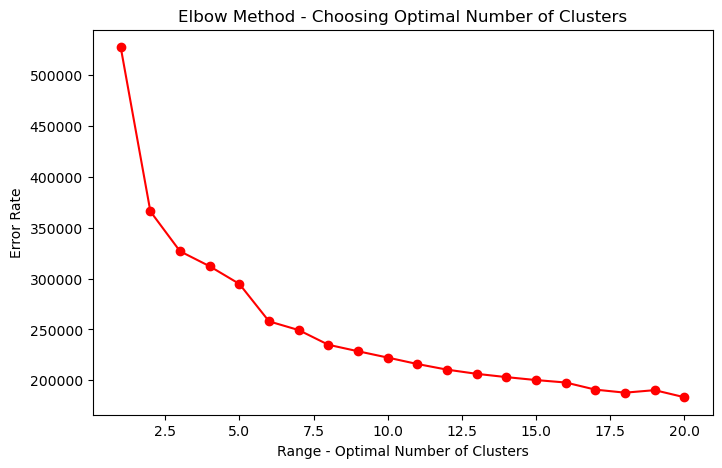

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rate, color='red', marker='o')
plt.xlabel('Range - Optimal Number of Clusters')
plt.ylabel('Error Rate')
plt.title('Elbow Method - Choosing Optimal Number of Clusters')

In [11]:
k = 4
model = KMeans(n_clusters=k)
clusters = model.fit_predict(X_scale)
df['clusters'] = clusters

In [12]:
df['clusters'].value_counts()

clusters
3    15032
0    12227
2     9462
1     7222
Name: count, dtype: int64

In [13]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,AgeGroup,Discount_Usage_Group,Customer_Value_Group,clusters
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,20.8,1.0,953.33,2278.0,0,Q1,46-55,Medium Discount Usage,Medium Value customer,2
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,23.3,3.0,1067.47,3028.0,0,Q4,46-55,Medium Discount Usage,Medium Value customer,3
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,8.8,2.0,1289.75,2317.0,0,Q4,46-55,Low Discount Usage,Medium Value customer,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,31.0,3.0,2340.92,2674.0,0,Q1,46-55,Medium Discount Usage,High Value customer,1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.0,19.1,9.0,...,50.4,4.0,3041.29,5354.0,0,Q4,36-45,Low Discount Usage,High Value customer,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43938,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,3.0,...,14.6,2.0,813.11,3565.0,1,Q2,26-35,Low Discount Usage,Low Value customer,0
43939,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,25.2,1.0,2365.98,3499.0,0,Q2,46-55,Medium Discount Usage,High Value customer,3
43940,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,12.1,4.0,1293.60,3154.0,0,Q3,46-55,High Discount Usage,Medium Value customer,3
43941,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,14.1,3.0,1286.11,2634.0,0,Q2,46-55,High Discount Usage,Medium Value customer,3


<Axes: xlabel='Login_Frequency', ylabel='Days_Since_Last_Purchase'>

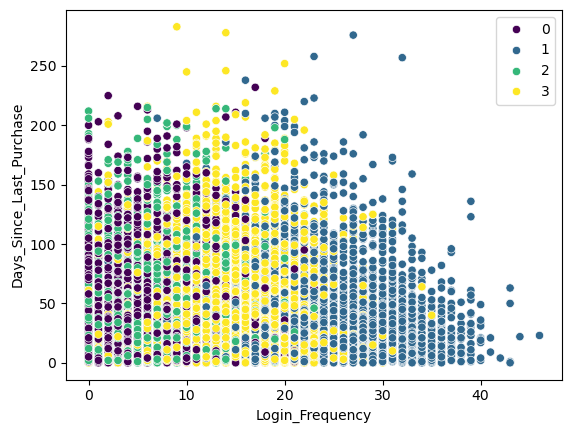

In [14]:
sns.scatterplot(x=df['Login_Frequency'], y=df['Days_Since_Last_Purchase'], hue=clusters, palette='viridis')

<Axes: xlabel='Login_Frequency', ylabel='Average_Order_Value'>

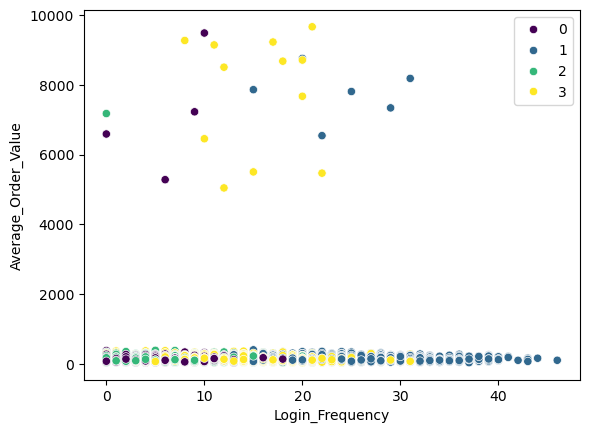

In [15]:
sns.scatterplot(x=df['Login_Frequency'], y=df['Average_Order_Value'], hue=clusters, palette='viridis')

In [16]:
cluster = model.labels_
df['cluster'] = cluster



In [17]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,AgeGroup,Discount_Usage_Group,Customer_Value_Group,clusters,cluster
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,1.0,953.33,2278.0,0,Q1,46-55,Medium Discount Usage,Medium Value customer,2,2
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,3.0,1067.47,3028.0,0,Q4,46-55,Medium Discount Usage,Medium Value customer,3,3
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,2.0,1289.75,2317.0,0,Q4,46-55,Low Discount Usage,Medium Value customer,0,0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,3.0,2340.92,2674.0,0,Q1,46-55,Medium Discount Usage,High Value customer,1,1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.0,19.1,9.0,...,4.0,3041.29,5354.0,0,Q4,36-45,Low Discount Usage,High Value customer,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43938,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,3.0,...,2.0,813.11,3565.0,1,Q2,26-35,Low Discount Usage,Low Value customer,0,0
43939,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,1.0,2365.98,3499.0,0,Q2,46-55,Medium Discount Usage,High Value customer,3,3
43940,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,4.0,1293.60,3154.0,0,Q3,46-55,High Discount Usage,Medium Value customer,3,3
43941,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,3.0,1286.11,2634.0,0,Q2,46-55,High Discount Usage,Medium Value customer,3,3


In [18]:
pair_pt = df

In [19]:
# sns.pairplot(
#     pair_pt,
#     hue='cluster'
# )

## principle component analysis (PCA)

In [20]:
total_customer =df.groupby('cluster').size().reset_index(name='Total_Customers')
total_customer


,cluster,Total_Customers
0,0,12227
1,1,7222
2,2,9462
3,3,15032


In [21]:

pca = PCA(n_components=len(segmentation_features))

In [22]:
# covariance
X_model = pca.fit_transform(X_scale)

In [23]:
X_model

array([[-0.68649255, -0.21402406,  0.2761221 , ..., -0.23216135,
        -0.69935979,  0.2016482 ],
       [ 2.00000714, -0.45377955,  1.45039148, ...,  0.83113544,
        -0.18137559,  0.63923668],
       [-2.18476051,  0.33445352, -1.53068629, ...,  0.01969619,
        -0.72325851,  0.91976594],
       ...,
       [ 0.93193446, -0.19784148,  1.32870526, ...,  0.49332757,
         0.19929292,  0.15636468],
       [ 0.45012478, -0.12360485,  2.07682169, ..., -0.02389222,
         0.4824793 ,  0.04326513],
       [-2.13081214,  0.16193095, -1.40595849, ...,  0.53025647,
         0.8502728 , -0.13200574]], shape=(43943, 12))

In [24]:

loadings = pd.DataFrame(
    pca.components_, # covariance -> eigenvalues and eigenvectors,
    index=segmentation_features,
    columns = [f'PC{i+1}' for i in range(len(segmentation_features))]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Login_Frequency,0.350044,0.371829,0.359519,-0.346788,0.338792,0.012423,0.002121,0.002345,0.330137,-0.224511,0.353621,0.300513
Session_Duration_Avg,-0.032651,-0.044478,-0.036460,0.040253,0.033348,0.950348,0.034420,0.013931,-0.055788,0.072976,-0.048294,0.278539
Pages_Per_Session,-0.009608,-0.006464,-0.007736,0.006051,0.047809,-0.036259,0.530953,0.844902,-0.003227,0.017885,-0.008257,-0.000690
Cart_Abandonment_Rate,0.007219,-0.002398,-0.001287,-0.002487,-0.019817,-0.018876,0.846464,-0.530997,-0.001858,-0.026587,0.000533,-0.003930
Total_Purchases,0.055622,0.051515,0.048504,-0.052004,0.150167,-0.109472,0.008892,-0.036273,0.072476,0.959019,0.057495,0.158082
Average_Order_Value,-0.175511,-0.133660,-0.167496,0.185380,0.457648,-0.258633,-0.015753,-0.032167,-0.273319,-0.148382,-0.189652,0.691814
Days_Since_Last_Purchase,-0.237880,-0.067658,-0.130248,0.319193,0.009862,-0.011575,0.000450,-0.005649,0.882291,-0.032714,-0.178721,0.090970
Discount_Usage_Rate,0.549091,0.058915,0.089106,0.793038,0.138776,0.023430,-0.001195,-0.003470,-0.083630,0.002676,0.129920,-0.120328
Email_Open_Rate,-0.648340,0.094062,0.206648,0.267943,0.111935,0.028148,0.003963,-0.008442,-0.093377,0.004517,0.652893,-0.088842
Customer_Service_Calls,-0.116467,0.037984,0.006420,-0.094172,0.762570,0.119119,-0.005130,-0.038440,-0.004773,-0.000839,-0.295035,-0.540192


Text(0, 0.5, 'Principle Component 2')

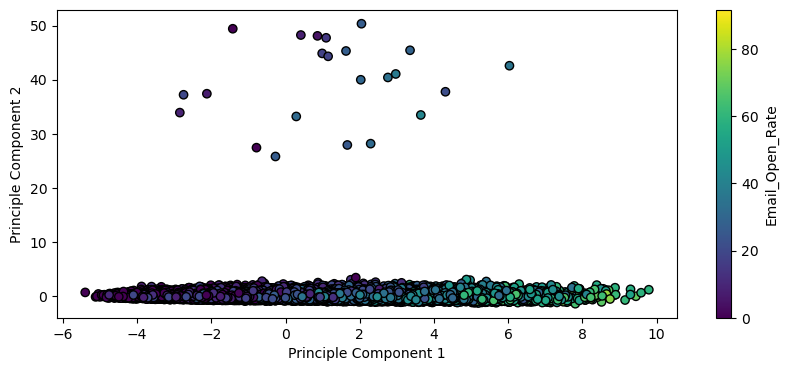

In [31]:
col = 'Email_Open_Rate'
plt.figure(figsize=(10, 4))
scatter = plt.scatter(X_model[:,0], X_model[:,1], c=df[col], edgecolor='black')
plt.colorbar(scatter, label=col)
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')

<mark>Analyze<mark>

- Dark dots = customers who rarely open emails
- Yellow/green dots = customers who open emails more
- Direction read from left to  right 
- most customer concentrated  near the bottom (0-3)  and  unusal customer between (25 -50)
